In [1]:
# Cells model for NN Pathways 1 2022 - v1.2 overview
# ----------------------------------------
# This file is used as a template base for the automated cell generator notebook.
# favicon in the cell above will be included in the broswer tab title.
# Version, author and date will be included as the first content.

# 🇳🇬 Northern Nigeria Segmentation Overview

<p>
Sonder Segmentation Science WS Team<br>
Data version: Pathways 2022 1 - v1.2
</p>

In [2]:
# Load libraries
import pandas as pd
import geopandas as gpd
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from plotly.subplots import make_subplots

# Configure Plotly renderer
# this enable chart in the exported HTML file
# https://github.com/microsoft/vscode-jupyter/issues/6999
pio.renderers.default = "notebook_connected"

In [3]:
# R Packages, libraries and utilities
import rpy2.robjects as ro
from rpy2.robjects import r, pandas2ri, default_converter
from rpy2.robjects.conversion import localconverter

In [4]:
# Check R version
r_version = ro.r('version')

In [5]:

pandas2ri.activate()
r('library(survey)')
r('library(base)')
r('library(dplyr)')

R[write to console]: Cargando paquete requerido: grid

R[write to console]: Cargando paquete requerido: Matrix

R[write to console]: Cargando paquete requerido: survival

R[write to console]: 
Adjuntando el paquete: ‘survey’


R[write to console]: The following object is masked from ‘package:graphics’:

    dotchart


R[write to console]: 
Adjuntando el paquete: ‘dplyr’


R[write to console]: The following objects are masked from ‘package:stats’:

    filter, lag


R[write to console]: The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [6]:
# load data
df = pd.read_csv("Nigeria_North_2022Pathways1_1.2.csv")

# Rename state column, to be used in charts
df.rename(columns={'STATE': 'State'}, inplace=True)
df["State"] = df["State"].str.title()

df_rural = df[df["URBAN_RURA"] == "R"].copy()
df_urban = df[df["URBAN_RURA"] == "U"].copy()

In [7]:
# Load your geojson data (replace with actual path)
geo_df = gpd.read_file('gadm41_NGA_1.json')

In [8]:
# Global variables required in the R runtime:
# ------------------------------------------

# Assign the R DataFrame to an R variable
ro.globalenv['nn'] = df
ro.globalenv['urban'] = df_urban
ro.globalenv['rural'] = df_rural

ro.r('nn$Segment <- factor(nn$class)')
ro.r('urban$Segment <- factor(urban$class)')
ro.r('rural$Segment <- factor(rural$class)')

# Define the survey design in R
# From Michael's design input (no strata used in complex survey design)
# id=~PSUclean, weights=~weight, data=survey_data, nest=TRUE
ro.r('urban.des <-svydesign(id=urban$PSUclean, weights=urban$weight, data=urban, nest=TRUE)')
ro.r('rural.des <-svydesign(id=rural$PSUclean, weights=rural$weight, data=rural, nest=TRUE)')
ro.r('nn.des <-svydesign(id=nn$PSUclean, weights=nn$weight, data=nn, nest=TRUE)')

/Users/ggojedap/.local/share/virtualenvs/HTML-reports-emoTyqDj/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning:

Error while trying to convert the column "caseid". Fall back to string conversion. The error is: integer 1041041160696104 does not fit '32-bit int'

/Users/ggojedap/.local/share/virtualenvs/HTML-reports-emoTyqDj/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning:

Error while trying to convert the column "caseid". Fall back to string conversion. The error is: integer 1101091161731367 does not fit '32-bit int'

/Users/ggojedap/.local/share/virtualenvs/HTML-reports-emoTyqDj/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning:

Error while trying to convert the column "anc.total". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before con

In [9]:
colors = {
    "Total": "#FFFFFF",  # White or transparent for root
    "Rural": "#7AC943",  # Blue for Rural category
    "Urban": "#7A8291",  # Green for Urban category
    # Rural segments
    "R2-NN": "#14ABF7",
    "R3.1-NN": "#8B7FEA",
    "R3.2-NN": "#B5A4EA",
    "R4-NN": "#F26185",
    # Urban segments
    "U1-NN": "#21D6D6",
    "U2-NN": "#14ABF7",
    "U3-NN": "#B5A4EA",
    "U4-NN": "#F26185"
}

colors_yes_no = {"Yes": "#88C1FD", "No": "#B3B3B3"}

In [10]:
def create_table(current_design: str,
                 var_of_interest: str,
                 labels: dict = {}) -> pd.DataFrame:
    """
    Create a contingency table with percentage and parcentege's SE 
    for each combination Segment - Category of var_of_interest
    """
    # 1) In R, calculate the table of frequencies
    r(f'''
      library(survey)
      current_table <- as.data.frame(
        svytable(~ Segment + {var_of_interest}, design = {current_design})
      )
      current_table$Segment <- as.character(current_table$Segment)
    ''')

    # 2) Take the data.frame from R and convert it to Pandas
    r_df = r('current_table')
    with localconverter(default_converter + pandas2ri.converter):
        df = pandas2ri.rpy2py(r_df)

    # 3) Calculate the percentage for each segment
    df['percentage'] = (
        df.groupby('Segment')['Freq']
          .transform(lambda x: x / x.sum() * 100)
          .round(2)
    )

    # 4) Apply labels (if any)
    if labels:
        inv = {v: k for k, v in labels.items()}
        df[var_of_interest] = (
            df[var_of_interest].astype(str)
                               .map(labels)
        )

    # 5) For each row, calculate the SE of the percentage, in R
    se_list = []
    for _, row in df.iterrows():
        seg = row['Segment']
        cat = row[var_of_interest]
        # take the original value of the category 
        cat_r = inv[cat] if labels else cat
        # in R, ratio (proportion) and SE with svymean of the indicator
        r_cmd = f'''
          prop <- svymean(
            ~I({var_of_interest}=="{cat_r}"),
            design = subset({current_design}, Segment=="{seg}"),
            na.rm=TRUE, se=TRUE
          )
          SE(prop)
        '''
        se_val = float(r(r_cmd)[0]) * 100
        se_list.append(round(se_val, 2))

    df['se_percentage'] = se_list

    return df

In [11]:
def create_bar_chart(current_data: pd.DataFrame,
                     var_of_interest: str,
                     title: str,
                     subtitle: str = None) -> px.bar:
    df = current_data.copy()

    # Prepare text and custom_data
    df["text_label"]  = df["percentage"].round(1).astype(str) + "%"
    df["current_val"] = df[var_of_interest]
    custom = ["current_val", "percentage", "se_percentage"]

    fig = px.bar(
        df,
        x='Segment',
        y='percentage',
        color=var_of_interest,
        text='text_label',
        custom_data=custom,
        labels={'percentage': 'Percentage', 'Segment': 'Segment'},
        title=title,
        barmode='stack',
        color_discrete_sequence=[
            "#88C1FD", "#AF73C8", "#66C2A5", "#FB8686", "#FFD92F", "#677BA1", "#B78C4E", "#E78AC3", "#A6D854", "#B3B3B3"
        ],
        color_discrete_map=colors_yes_no
    )

    # Hover template to show percentage and SE
    hover = (
        "<b>%{customdata[0]}</b><br>"           # original value
        "Segment: %{x}<br>"
        "Percentage: %{customdata[1]:.1f}%<br>"
        "SE: %{customdata[2]:.1f}%<extra></extra>"
    )
    fig.update_traces(
        textposition='auto',
        cliponaxis=False,
        textfont_size=16,
        hovertemplate=hover
    )

    # Layout and subtitle (if any)
    fig.update_layout(
        title={
            'text': title, 'x': 0.5, 'xanchor': 'center',
            'font': dict(size=24, family="Arial", color="#333")
        },
        plot_bgcolor='#fcfcf7',
        margin=dict(t=100),
        legend_title_text=var_of_interest
    )
    if subtitle:
        fig.add_annotation(
            text=subtitle, x=0.5, y=1.125,
            xref="paper", yref="paper", showarrow=False,
            font=dict(size=14, color="gray"), xanchor="center"
        )
    return fig

In [12]:
# Calculate stats for a numeric variable, by segment
# min, max, q1, q3, median
def create_stats(current_design, var_of_interest):
  r_code = """
  median <- svyby(~{voi}, ~Segment, {cd}, svyquantile, quantiles = c(0.5), na.rm = TRUE)
  median <- median %>% rename(median = {voi})
  q1 <- svyby(~{voi}, ~Segment, {cd}, svyquantile, quantiles = c(0.25), na.rm = TRUE)
  q1 <- q1 %>%  rename(q1 = {voi})
  q3 <- svyby(~{voi}, ~Segment, {cd}, svyquantile, quantiles = c(0.75), na.rm = TRUE)
  q3 <- q3 %>%  rename(q3 = {voi})
  min <- svyby(~{voi}, ~Segment, {cd}, svyquantile, quantiles = c(0.0), na.rm = TRUE)
  min <- min %>% rename(min = {voi})
  max <- svyby(~{voi}, ~Segment, {cd}, svyquantile, quantiles = c(1.0), na.rm = TRUE)
  max <- max %>% rename(max = {voi})

  stats <- full_join(q1, q3, by = "Segment")
  stats <- full_join(stats, median, by = "Segment")
  stats <- full_join(stats, min, by = "Segment")
  stats <- full_join(stats, max, by = "Segment")

  stats <- stats %>% 
    select("Segment", "min", "q1", "median", "q3", "max")
  """.format(voi=var_of_interest, cd=current_design)

  ro.r(r_code)
  table_stats = ro.r('stats')

  # conversion
  with (ro.default_converter + pandas2ri.converter).context():
          table_stats = ro.conversion.get_conversion().rpy2py(table_stats) 

  return table_stats

In [13]:
def create_box_plot(current_data, var_of_interest, title):
  # Create the box plot
  fig = px.box(
      current_data,
      x="Segment",
      y=["min", "q1", "median", "q3", "max"],
      title="Metrics for " + var_of_interest,
      points=False,  # This hides individual points. "all" to show them
      color="Segment",
      color_discrete_map=colors  # Use custom colors
  )

  # Update layout for better visualization
  fig.update_layout(
      xaxis_title="Segment",
      yaxis_title=var_of_interest,
      title_x=0.5,  # Center the title
      showlegend=True
  )

  # Plot ready to be shown
  return fig

In [14]:
# table cell example, can be removed from template
# for the variable anc.less4 you use:
# -------------------------------------------------
# table_toilet_type = create_table("nn.des", "toilet.type", {"1": "Flush", "2": "Latrine", "3": "Bucket"})

In [15]:
# chart cell example, can be removed from template
# for the variable anc.less4 you use:
# -------------------------------------------------
# create_bar_chart(table_toilet_type, "toilet.type", "Toilet Type", "A long text to test subtitles").show()

In [16]:
# table cell example, can be removed from template
# for the variable partner.age (numeric) you use:
# -------------------------------------------------
# table_partner_age = create_stats("nn.des", "partner.age")
# display(table_partner_age)

In [17]:
# Box plot cell example, can be removed from template
# for the variable partner.age (numeric) you use:
# -------------------------------------------------
# create_box_plot(table_partner_age, "partner.age")

## General Distribution

### Rural Segments

In [18]:
# RURAL Segments 
ro.r('table_dist_rural <- as.data.frame(svytable(~Segment, design = rural.des))')
ro.r('table_dist_rural$Segment <- as.character(table_dist_rural$Segment)')
table_dist_rural = ro.r('table_dist_rural')

# conversion
with (ro.default_converter + pandas2ri.converter).context():
        table_dist_rural = ro.conversion.get_conversion().rpy2py(table_dist_rural)  

# calculate percentage
current_total = table_dist_rural['Freq'].sum()
table_dist_rural['percentage'] = table_dist_rural['Freq'] / current_total * 100

display(table_dist_rural.style.format({'Freq': '{:.0f}', 'percentage': '{:.1f}%'}))

,Segment,Freq,percentage
1,R2-NN,707,32.2%
2,R3.1-NN,554,25.2%
3,R3.2-NN,528,24.0%
4,R4-NN,408,18.6%


### Urban Segments

In [19]:
# URBAN Segments 
ro.r('table_dist_urban <- as.data.frame(svytable(~Segment, design = urban.des))')
ro.r('table_dist_urban$Segment <- as.character(table_dist_urban$Segment)')
table_dist_urban = ro.r('table_dist_urban')

# conversion
with (ro.default_converter + pandas2ri.converter).context():
        table_dist_urban = ro.conversion.get_conversion().rpy2py(table_dist_urban)  

# calculate percentage
current_total = table_dist_urban['Freq'].sum()
table_dist_urban['percentage'] = table_dist_urban['Freq'] / current_total * 100

display(table_dist_urban.style.format({'Freq': '{:.0f}', 'percentage': '{:.1f}%'}))

,Segment,Freq,percentage
1,U1-NN,259,25.1%
2,U2-NN,149,14.4%
3,U3-NN,294,28.5%
4,U4-NN,331,32.0%


### National Distribution

In [20]:
# All NN Segments 
ro.r('table_dist_nn <- as.data.frame(svytable(~Segment, design = nn.des))')
ro.r('table_dist_nn$Segment <- as.character(table_dist_nn$Segment)')
table_dist_nn = ro.r('table_dist_nn')

# conversion
with (ro.default_converter + pandas2ri.converter).context():
        table_dist_nn = ro.conversion.get_conversion().rpy2py(table_dist_nn)  

# calculate percentage
current_total = table_dist_nn['Freq'].sum()
table_dist_nn['percentage'] = table_dist_nn['Freq'] / current_total * 100
table_dist_nn['Type'] = table_dist_nn['Segment'].apply(lambda x: 'Rural' if x.startswith('R') else 'Urban')

display(table_dist_nn.style.format({'Freq': '{:.0f}', 'percentage': '{:.1f}%'}))

,Segment,Freq,percentage,Type
1,R2-NN,707,21.9%,Rural
2,R3.1-NN,554,17.2%,Rural
3,R3.2-NN,528,16.3%,Rural
4,R4-NN,408,12.6%,Rural
5,U1-NN,259,8.0%,Urban
6,U2-NN,149,4.6%,Urban
7,U3-NN,294,9.1%,Urban
8,U4-NN,331,10.2%,Urban


In [21]:
# Prepare data for 2 level pie chart (sunburst)
def prepare_sunburst_data(df):
    # Create a copy to avoid modifying the original
    df_sunburst = df.copy()
    
    # Add a root node and type nodes
    root_and_types = pd.DataFrame({
        'Segment': ['Total', 'Rural', 'Urban'],
        'Type': ['', 'Total', 'Total'],  # Empty string for root, Total for Rural/Urban
        'percentage': [100, 
                      df[df['Type'] == 'Rural']['percentage'].sum(),
                      df[df['Type'] == 'Urban']['percentage'].sum()]
    })
    
    # Modify the Type column to point to Rural or Urban instead of Total
    df_sunburst['Type'] = df_sunburst['Type']
    
    # Combine the root and type rows with the data
    df_sunburst = pd.concat([root_and_types, df_sunburst], ignore_index=True)
    
    return df_sunburst

# Prepare the data
sunburst_data = prepare_sunburst_data(table_dist_nn)

In [22]:
# Function to map colors based on the dictionary
def map_colors(df, color_dict):
    return [color_dict[segment] for segment in df['Segment']]

# Create a subplot with two charts (side by side)
fig = make_subplots(
    rows=1, cols=3,  # 1 row and 3 columns
    specs=[[{"type": "pie"}, {"type": "pie"}, {"type": "sunburst"}]],  # Specify type of chart
    subplot_titles=("Rural Distribution", "Urban Distribution", "National Distribution")  # Titles for the subplots
)

# Add the pie chart for table_dist_rural
fig.add_trace(
    go.Pie(
        labels=table_dist_rural['Segment'],
        values=table_dist_rural['percentage'],
        marker=dict(colors=map_colors(table_dist_rural, colors)),  # Apply custom colors
        direction='clockwise',  # Set rotation to clockwise
        sort=False,
        hovertemplate='<b>%{label}</b><br>' +
                      'Percentage: %{value:.2f}%<br>' +
                      '<extra></extra>'  # This removes the secondary box in the hover
    ),
    row=1, col=1  # First row, first column
)

# Add the pie chart for table_dist_urban
fig.add_trace(
    go.Pie(
        labels=table_dist_urban['Segment'],
        values=table_dist_urban['percentage'],
        marker=dict(colors=map_colors(table_dist_urban, colors)),  # Apply custom colors
        direction='clockwise',  # Set rotation to clockwise
        sort=False,
        hovertemplate='<b>%{label}</b><br>' +
                      'Percentage: %{value:.2f}%<br>' +
                      '<extra></extra>'  # This removes the secondary box in the hover
    ),
    row=1, col=2  # First row, second column
)

# Modified sunburst trace
fig.add_trace(
    go.Sunburst(
        ids=sunburst_data['Segment'],
        labels=sunburst_data['Segment'],
        parents=sunburst_data['Type'],
        values=sunburst_data['percentage'],
        marker=dict(colors=map_colors(sunburst_data, colors)),
        branchvalues='total',
        hovertemplate='<b>%{label}</b><br>' +
                      'Percentage: %{value:.2f}%<br>' +
                      '<extra></extra>'  # This removes the secondary box in the hover
    ),
    row=1, col=3
)

# Configure the layout and enforce the category order
fig.update_layout(
    title_text="Segment Distribution",  # Overall title
    title_x=0.5,  # Center the title
    annotations=[{"font": {"size": 14}}]  # Adjust the size of the subplot titles
)

# Show the chart
fig.show()


## Age Distribution

In [23]:
table_age_stats = create_table("nn.des", "her.age", {"1": "<19", "2": "20-24", "3": "25-29", "4": "30+"})
display(table_age_stats.style.format({'Freq': '{:.0f}', 'percentage': '{:.1f}%', 'se_percentage': '{:.1f}%'}))

,Segment,her.age,Freq,percentage,se_percentage
1,R2-NN,<19,23,3.3%,0.9%
2,R3.1-NN,<19,32,5.8%,1.4%
3,R3.2-NN,<19,39,7.3%,1.7%
4,R4-NN,<19,14,3.5%,1.3%
5,U1-NN,<19,2,0.7%,0.4%
6,U2-NN,<19,6,4.0%,1.6%
7,U3-NN,<19,10,3.3%,1.0%
8,U4-NN,<19,10,3.0%,0.9%
9,R2-NN,20-24,185,26.2%,2.4%
10,R3.1-NN,20-24,129,23.3%,2.5%


In [24]:
create_bar_chart(table_age_stats, "her.age", "Distribution by Age Group")

## Geographic Distribution

In [25]:
table_geo_dist_rural = create_table("rural.des", "State")

# calculate alternative percentage
inner_total = table_geo_dist_rural.groupby('State')['Freq'].transform('sum')
table_geo_dist_rural['percentage_state'] = table_geo_dist_rural['Freq'] / inner_total * 100

table_geo_dist_urban = create_table("urban.des", "State")

# calculate alternative percentage
inner_total = table_geo_dist_urban.groupby('State')['Freq'].transform('sum')
table_geo_dist_urban['percentage_state'] = table_geo_dist_urban['Freq'] / inner_total * 100

/var/folders/xf/6wcqzpvn6z32xyywdmn1919c0000gn/T/ipykernel_83203/1118792274.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/xf/6wcqzpvn6z32xyywdmn1919c0000gn/T/ipykernel_83203/1118792274.py:10: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [26]:
# Map with pie charts over each state
# -----------------------------------

# Create the subplots
fig = make_subplots(
    rows=1, cols=2,  # 1 row and 2 columns
    subplot_titles=("Urban Distribution by State", "Rural Distribution by State")  # Titles for the plots
)

# Create a set to track segments already added to the legend
legend_segments = set()

# Urban chart (left side)
for segment in table_geo_dist_urban['Segment'].unique():
    segment_data = table_geo_dist_urban[table_geo_dist_urban['Segment'] == segment]
    fig.add_trace(
        go.Bar(
            x=segment_data['State'],
            y=segment_data['percentage_state'],
            name=segment,  # Segment name for the legend
            legendgroup=segment,  # Same legend group for urban and rural
            showlegend=(segment not in legend_segments),  # Show legend only if not already added
            marker=dict(color=colors.get(segment, "#CCCCCC")),  # Use custom color or default to gray
            text=[f'{x:.1f}%' for x in segment_data['percentage_state']],  
            textposition='inside',  
            hovertemplate='<b>%{x}</b><br>' +
                         'Segment: ' + segment + '<br>' +
                         'Percentage: %{y:.1f}%<br>' +
                         '<extra></extra>'  # This removes the secondary box in the hover
        ),
        row=1, col=1  # Left chart
    )
    legend_segments.add(segment)  # Mark the segment as added

# Rural chart (right side)
for segment in table_geo_dist_rural['Segment'].unique():
    segment_data = table_geo_dist_rural[table_geo_dist_rural['Segment'] == segment]
    fig.add_trace(
        go.Bar(
            x=segment_data['State'],
            y=segment_data['percentage_state'],
            name=segment,  # Segment name for the legend
            legendgroup=segment,  # Same legend group for urban and rural
            showlegend=(segment not in legend_segments),  # Show legend only if not already added
            marker=dict(color=colors.get(segment, "#CCCCCC")),  # Use custom color or default to gray
            text=[f'{x:.1f}%' for x in segment_data['percentage_state']],  
            textposition='inside',  
            hovertemplate='<b>%{x}</b><br>' +
                         'Segment: ' + segment + '<br>' +
                         'Percentage: %{y:.1f}%<br>' +
                         '<extra></extra>'  # This removes the secondary box in the hover
        ),
        row=1, col=2  # Right chart
    )
    legend_segments.add(segment)  # Mark the segment as added

# Configure the layout
fig.update_layout(
    title="Segment Distribution by State (Urban vs Rural)",
    barmode='stack',  # Stack the bars
    title_x=0.5,  # Center the title
    xaxis_title="State",
    yaxis_title="Percentage",
    legend_title="Segment",
)

# Display the charts
fig.show()


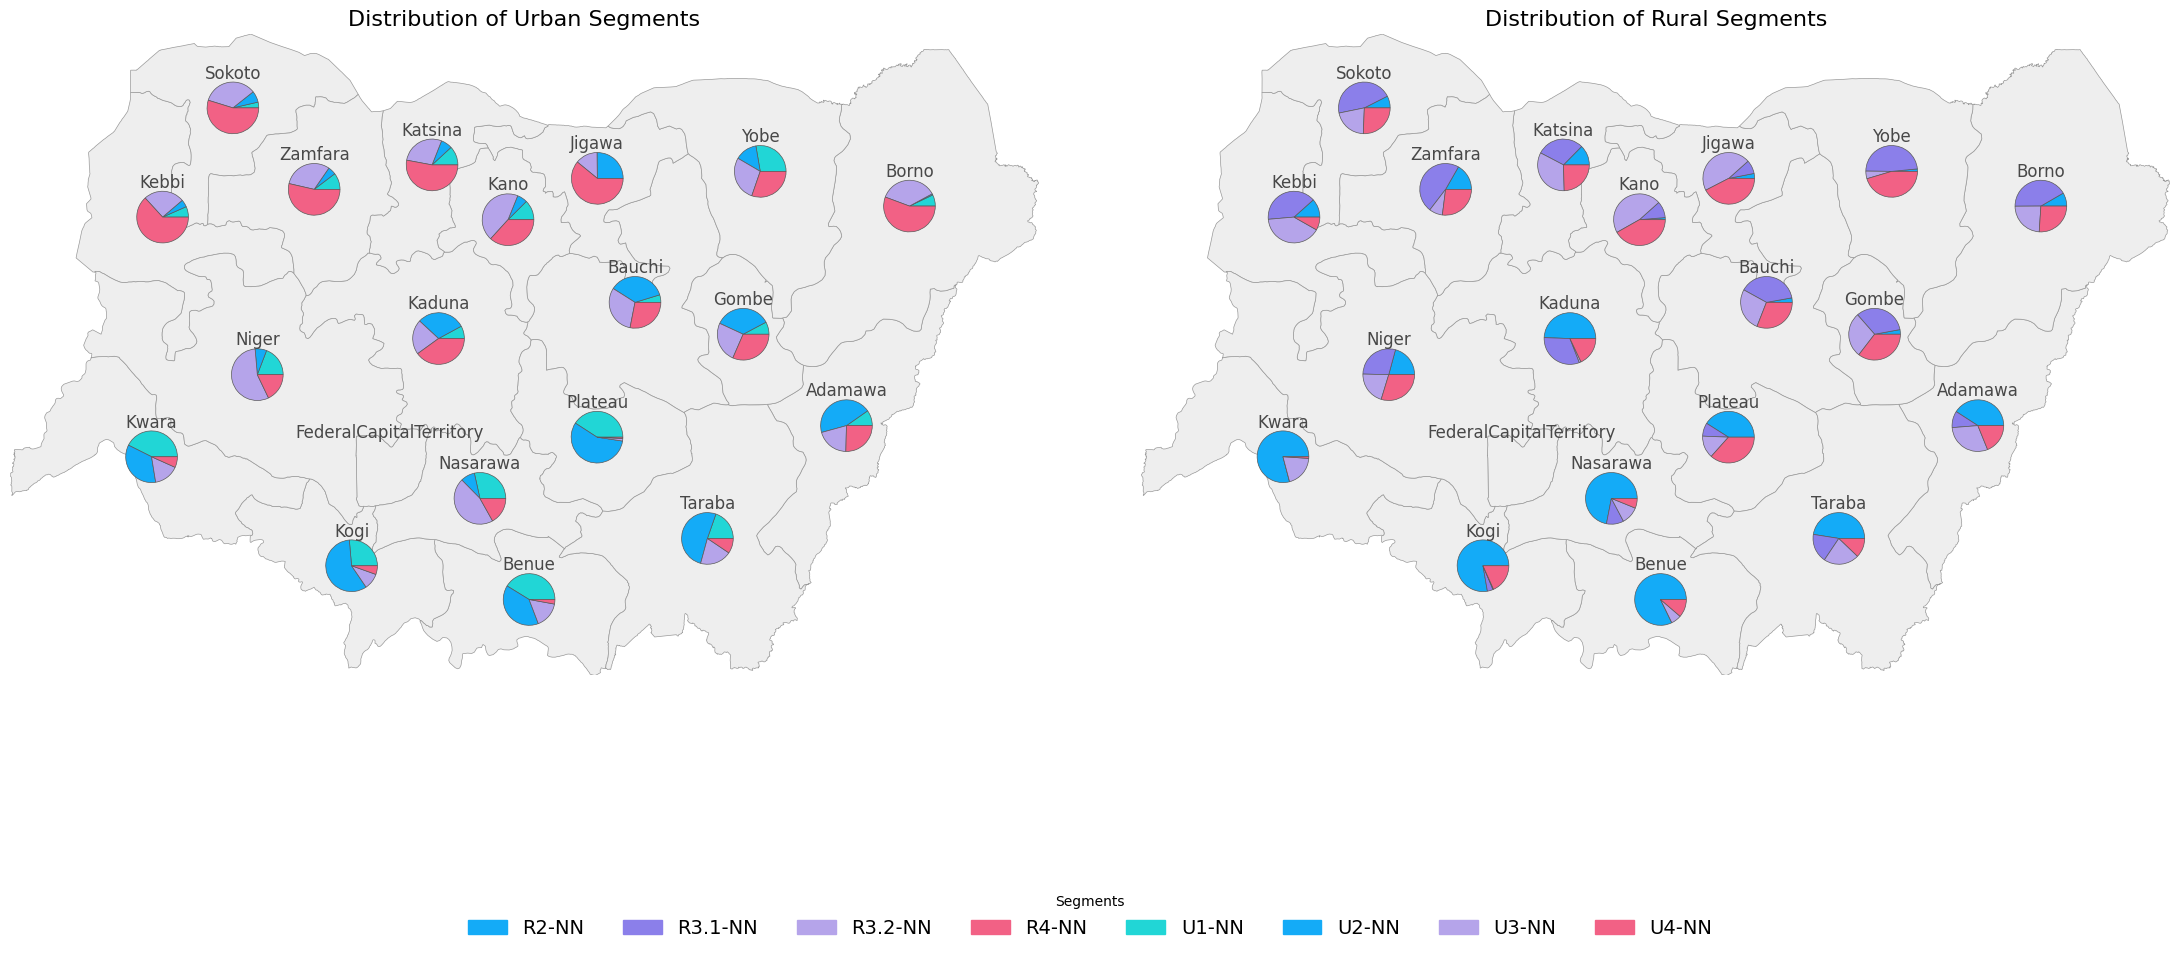

In [27]:
# Create the base map with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(24, 12))  # Two maps side by side

# Plot the base map
geo_df.plot(ax=axes[0], color='#EEE', edgecolor='#999', linewidth=0.5)
axes[0].set_title('Distribution of Urban Segments', fontsize=16)

def plot_pie_for_state(state, x, y, current_table, colors, ax):
    inner_current_table = current_table[current_table['State'] == state]
    
    # Ensure we plot only if there's valid data for this state
    if not inner_current_table.empty:
        sizes = inner_current_table['percentage']
        classes = inner_current_table['Segment']  # Get class names for each segment
        
         # Map each class to its corresponding color using the dictionary
        cls = [colors.get(cl, '#CCCCCC') for cl in classes]  # Default to gray if class not in dict
        ax.pie(sizes, center=(x, y), radius=0.3, colors=cls, wedgeprops=dict(edgecolor='#595959', linewidth=0.5))

# Plot pie charts for urban data
for idx, row in geo_df.iterrows():
    state = row['NAME_1']  # Adjust based on your GeoJSON structure
    centroid = row.geometry.centroid
    plot_pie_for_state(state, centroid.x, centroid.y, table_geo_dist_urban, colors, axes[0])
    # Add state name as a label near the centroid
    axes[0].text(centroid.x, centroid.y + 0.4, state, fontsize=12, ha='center', va='center', color='#484848')

# Plot the second map with rural data
geo_df.plot(ax=axes[1], color='#EEE', edgecolor='#999', linewidth=0.5)
axes[1].set_title('Distribution of Rural Segments', fontsize=16)

# Plot pie charts for rural data
for idx, row in geo_df.iterrows():
    state = row['NAME_1']  # Adjust based on your GeoJSON structure
    centroid = row.geometry.centroid
    plot_pie_for_state(state, centroid.x, centroid.y, table_geo_dist_rural, colors, axes[1])
    # Add state name as a label near the centroid
    axes[1].text(centroid.x, centroid.y + 0.4, state, fontsize=12, ha='center', va='center', color='#484848')

# Add a legend for the pie chart colors excluding Total, Rural, and Urban
excluded_segments = {"Total", "Rural", "Urban"}
legend_handles = [
    mpatches.Patch(color=color, label=segment)
    for segment, color in sorted(colors.items()) if segment not in excluded_segments
]
fig.legend(handles=legend_handles, loc='lower center', ncol=9, fontsize=14, frameon=False, title="Segments")

# Set map limits and hide axes
for ax in axes:
    ax.set_xlim(geo_df.total_bounds[0], geo_df.total_bounds[2])
    ax.set_ylim(geo_df.total_bounds[1], geo_df.total_bounds[3])
    ax.axis('off')

# Adjust layout for a cleaner appearance
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0.1)  # Adjust spacing between subplots

# Show the maps
plt.show()

## 1. Outcomes

### 1.1. Child's health and nutrition

#### 1.1.1. Child breastfed for 6 mos
*Variable name:* `breastfed.6mo`

In [28]:
table_breastfed_6mo = create_table("nn.des", "breastfed.6mo", labels={'0': 'No', '1': 'Yes'})

In [29]:
create_bar_chart(table_breastfed_6mo, "breastfed.6mo", "Child breastfed for 6 mos", "Whether the last child was breastfed for at least 6 months").show()

#### 1.1.2. Death of a child before 5 yrs
*Variable name:* `death.u5`

In [30]:
table_death_u5 = create_table("nn.des", "death.u5", labels={'0': 'No', '1': 'Yes'})

In [31]:
create_bar_chart(table_death_u5, "death.u5", "Death of a child before 5 yrs", "Whether had child born alive but died before 5 years old").show()

#### 1.1.3. Child ever hospitalized
*Variable name:* `kid.hosp`

In [32]:
table_kid_hosp = create_table("nn.des", "kid.hosp", labels={'0': 'No', '1': 'Yes'})

In [33]:
create_bar_chart(table_kid_hosp, "kid.hosp", "Child ever hospitalized", "Whether any kid hospitalized").show()

#### 1.1.4. Child illness in last 3 mos
*Variable name:* `kid.ill.3mo`

In [34]:
table_kid_ill_3mo = create_table("nn.des", "kid.ill.3mo", labels={'0': 'No', '1': 'Yes'})

In [35]:
create_bar_chart(table_kid_ill_3mo, "kid.ill.3mo", "Child illness in last 3 mos", "Whether children had any of the above illness").show()

#### 1.1.5. Child ill >3 times in last 3 mos
*Variable name:* `kid.ill.3plus`

In [36]:
table_kid_ill_3plus = create_table("nn.des", "kid.ill.3plus", labels={'0': 'No', '1': 'Yes'})

In [37]:
create_bar_chart(table_kid_ill_3plus, "kid.ill.3plus", "Child ill >3 times in last 3 mos", "Whether children has more than 3 illness").show()

#### 1.1.6. No. of child illness in last 3 mos
*Variable name:* `kid.ill.sum`

In [38]:
stats_kid_ill_sum = create_stats("nn.des", "kid.ill.sum")

In [39]:
create_box_plot(stats_kid_ill_sum, "kid.ill.sum", "No. of child illness in last 3 mos").show()

#### 1.1.7. Stunted child
*Variable name:* `kid.stunt`

In [40]:
table_kid_stunt = create_table("nn.des", "kid.stunt", labels={'0': 'No', '1': 'Yes'})

In [41]:
create_bar_chart(table_kid_stunt, "kid.stunt", "Stunted child", "Whether has any child stunting").show()

### 1.2. Pregnancy

#### 1.2.1. First ANC visit in 1st trimester
*Variable name:* `anc.1sttri`

In [42]:
table_anc_1sttri = create_table("nn.des", "anc.1sttri", labels={'0': 'No', '1': 'Yes'})

In [43]:
create_bar_chart(table_anc_1sttri, "anc.1sttri", "First ANC visit in 1st trimester", "ANC started In 1st trimester").show()

#### 1.2.2. 4+ ANC visits
*Variable name:* `anc.4plus`

In [44]:
table_anc_4plus = create_table("nn.des", "anc.4plus", labels={'0': 'No', '1': 'Yes'})

In [45]:
create_bar_chart(table_anc_4plus, "anc.4plus", "4+ ANC visits", "Had 4+ ANC visits during the last pregancy").show()

#### 1.2.3. Month of first ANC visit
*Variable name:* `anc.start`

In [46]:
stats_anc_start = create_stats("nn.des", "anc.start")

In [47]:
create_box_plot(stats_anc_start, "anc.start", "Month of first ANC visit").show()

#### 1.2.4. Any home birth (daughter)
*Variable name:* `hb.dau.yn`

In [48]:
table_hb_dau_yn = create_table("nn.des", "hb.dau.yn", labels={'0': 'No', '1': 'Yes'})

In [49]:
create_bar_chart(table_hb_dau_yn, "hb.dau.yn", "Any home birth (daughter)", "Whether she has delivered a daughter at home").show()

#### 1.2.5. Any home birth (son)
*Variable name:* `hb.son.yn`

In [50]:
table_hb_son_yn = create_table("nn.des", "hb.son.yn", labels={'0': 'No', '1': 'Yes'})

In [51]:
create_bar_chart(table_hb_son_yn, "hb.son.yn", "Any home birth (son)", "Whether she has delivered a son at home").show()

#### 1.2.6. No. of home births
*Variable name:* `hb.sum`

In [52]:
stats_hb_sum = create_stats("nn.des", "hb.sum")

In [53]:
create_box_plot(stats_hb_sum, "hb.sum", "No. of home births").show()

#### 1.2.7. More than 3 home births
*Variable name:* `hb.sum.3plus`

In [54]:
table_hb_sum_3plus = create_table("nn.des", "hb.sum.3plus", labels={'0': 'No', '1': 'Yes'})

In [55]:
create_bar_chart(table_hb_sum_3plus, "hb.sum.3plus", "More than 3 home births", "Whether she has had 3 or more home births").show()

#### 1.2.8. Any home birth
*Variable name:* `hb.sum.yn`

In [56]:
table_hb_sum_yn = create_table("nn.des", "hb.sum.yn", labels={'0': 'No', '1': 'Yes'})

In [57]:
create_bar_chart(table_hb_sum_yn, "hb.sum.yn", "Any home birth", "Whether she has ever delivered a baby at home").show()

#### 1.2.9. Currently pregnant
*Variable name:* `preg.current`

In [58]:
table_preg_current = create_table("nn.des", "preg.current", labels={'0': 'No', '1': 'Yes'})

In [59]:
create_bar_chart(table_preg_current, "preg.current", "Currently pregnant", "Whether currently pregnant").show()

#### 1.2.10. No. of live births
*Variable name:* `preg.live`

In [60]:
stats_preg_live = create_stats("nn.des", "preg.live")

In [61]:
create_box_plot(stats_preg_live, "preg.live", "No. of live births").show()

#### 1.2.11. Pregnancy loss
*Variable name:* `preg.loss`

In [62]:
table_preg_loss = create_table("nn.des", "preg.loss", labels={'0': 'No', '1': 'Yes'})

In [63]:
create_bar_chart(table_preg_loss, "preg.loss", "Pregnancy loss", "Whether had any pregnancy loss").show()

#### 1.2.12. No. of pregnancies
*Variable name:* `preg.num`

In [64]:
stats_preg_num = create_stats("nn.des", "preg.num")

In [65]:
create_box_plot(stats_preg_num, "preg.num", "No. of pregnancies").show()

#### 1.2.13. Pregnancy risk counseling
*Variable name:* `preg.risk`

In [66]:
table_preg_risk = create_table("nn.des", "preg.risk", labels={'0': 'No', '1': 'Yes'})

In [67]:
create_bar_chart(table_preg_risk, "preg.risk", "Pregnancy risk counseling", "Whether any of the above risk was true").show()

### 1.3. Reproductive Health

#### 1.3.1. Current FP use
*Variable name:* `fp.current.any`

In [68]:
table_fp_current_any = create_table("nn.des", "fp.current.any", labels={'0': 'No', '1': 'Yes'})

In [69]:
create_bar_chart(table_fp_current_any, "fp.current.any", "Current FP use", "Whether she is currently using any FP").show()

#### 1.3.2. Current modern FP use
*Variable name:* `fp.current.modern`

In [70]:
table_fp_current_modern = create_table("nn.des", "fp.current.modern", labels={'0': 'No', '1': 'Yes'})

In [71]:
create_bar_chart(table_fp_current_modern, "fp.current.modern", "Current modern FP use", "Whether she is currently using modern FP").show()

#### 1.3.3. Past FP use
*Variable name:* `fp.previous.any`

In [72]:
table_fp_previous_any = create_table("nn.des", "fp.previous.any", labels={'0': 'No', '1': 'Yes'})

In [73]:
create_bar_chart(table_fp_previous_any, "fp.previous.any", "Past FP use", "Whether she ever used any FP").show()

#### 1.3.4. Past modern FP use
*Variable name:* `fp.previous.modern`

In [74]:
table_fp_previous_modern = create_table("nn.des", "fp.previous.modern", labels={'0': 'No', '1': 'Yes'})

In [75]:
create_bar_chart(table_fp_previous_modern, "fp.previous.modern", "Past modern FP use", "Whether she ever used any modern FP").show()

### 1.4. Woman's Health & Wellbeing

#### 1.4.1. Low stress/depression score
*Variable name:* `depress`

In [76]:
table_depress = create_table("nn.des", "depress", labels={'0': 'No', '1': 'Yes'})

In [77]:
create_bar_chart(table_depress, "depress", "Low stress/depression score", "Whether has stree and pression in general (take depress.mean < 3, because 1=always, 2= most of the time, 3=half the time, 4=rarely, 5=never)").show()

#### 1.4.2. Mean stress/depression score
*Variable name:* `depress.mean`

In [78]:
stats_depress_mean = create_stats("nn.des", "depress.mean")

In [79]:
create_box_plot(stats_depress_mean, "depress.mean", "Mean stress/depression score").show()

#### 1.4.3. Ill >4 times in last 3 mos
*Variable name:* `her.ill.4plus`

In [80]:
table_her_ill_4plus = create_table("nn.des", "her.ill.4plus", labels={'0': 'No', '1': 'Yes'})

In [81]:
create_bar_chart(table_her_ill_4plus, "her.ill.4plus", "Ill >4 times in last 3 mos", "Whether she had more than 4 illness").show()

#### 1.4.4. No. of illness in last 3 mos
*Variable name:* `her.ill.sum`

In [82]:
stats_her_ill_sum = create_stats("nn.des", "her.ill.sum")

In [83]:
create_box_plot(stats_her_ill_sum, "her.ill.sum", "No. of illness in last 3 mos").show()

#### 1.4.5. Wasted
*Variable name:* `her.wasting`

In [84]:
table_her_wasting = create_table("nn.des", "her.wasting", labels={'0': 'No', '1': 'Yes'})

In [85]:
create_bar_chart(table_her_wasting, "her.wasting", "Wasted", "Whether woman is wasting").show()

## 2. Defining Variables

### 2.1. Health mental models

#### 2.1.1. Access problem: travel alone
*Variable name:* `alone`

In [86]:
table_alone = create_table("nn.des", "alone", labels={'0': 'No', '1': 'Yes'})

In [87]:
create_bar_chart(table_alone, "alone", "Access problem: travel alone", "Going alone to the doctor is a big problem").show()

#### 2.1.2. Planned delivery: home
*Variable name:* `deliver.home.prefer`

In [88]:
table_deliver_home_prefer = create_table("nn.des", "deliver.home.prefer", labels={'0': 'No', '1': 'Yes'})

In [89]:
create_bar_chart(table_deliver_home_prefer, "deliver.home.prefer", "Planned delivery: home", "Whether she prefers to deliver at home").show()

#### 2.1.3. Planned delivery: hospital
*Variable name:* `deliver.hos.prefer`

In [90]:
table_deliver_hos_prefer = create_table("nn.des", "deliver.hos.prefer", labels={'0': 'No', '1': 'Yes'})

In [91]:
create_bar_chart(table_deliver_hos_prefer, "deliver.hos.prefer", "Planned delivery: hospital", "Whether she prefers to deliver at hospitals (incl. public and private)").show()

#### 2.1.4. Planned delivery: public hospital
*Variable name:* `deliver.pubhos.prefer`

In [92]:
table_deliver_pubhos_prefer = create_table("nn.des", "deliver.pubhos.prefer", labels={'0': 'No', '1': 'Yes'})

In [93]:
create_bar_chart(table_deliver_pubhos_prefer, "deliver.pubhos.prefer", "Planned delivery: public hospital", "Whether she prefers to deliver at public hospital").show()

#### 2.1.5. Access problem: distance
*Variable name:* `distance`

In [94]:
table_distance = create_table("nn.des", "distance", labels={'0': 'No', '1': 'Yes'})

In [95]:
create_bar_chart(table_distance, "distance", "Access problem: distance", "Distance to the doctor is a big problem").show()

#### 2.1.6. Access problem: total
*Variable name:* `med.index`

In [96]:
stats_med_index = create_stats("nn.des", "med.index")

In [97]:
create_box_plot(stats_med_index, "med.index", "Access problem: total").show()

#### 2.1.7. Access problem: at least two
*Variable name:* `med.index.2plus`

In [98]:
table_med_index_2plus = create_table("nn.des", "med.index.2plus", labels={'0': 'No', '1': 'Yes'})

In [99]:
create_bar_chart(table_med_index_2plus, "med.index.2plus", "Access problem: at least two", "Whether she perceives 2 or more barriers to healthcare").show()

#### 2.1.8. Access problem: any
*Variable name:* `med.index.yn`

In [100]:
table_med_index_yn = create_table("nn.des", "med.index.yn", labels={'0': 'No', '1': 'Yes'})

In [101]:
create_bar_chart(table_med_index_yn, "med.index.yn", "Access problem: any", "Whether she perceives any barriers to healthcare").show()

#### 2.1.9. Access problem: cost
*Variable name:* `money`

In [102]:
table_money = create_table("nn.des", "money", labels={'0': 'No', '1': 'Yes'})

In [103]:
create_bar_chart(table_money, "money", "Access problem: cost", "Cost to go to the doctor is a big problem").show()

#### 2.1.10. Delay in care seeking
*Variable name:* `percept.child.sick`

In [104]:
table_percept_child_sick = create_table("nn.des", "percept.child.sick", labels={'1': 'Mother was waiting for more severe symptoms to appear', '2': 'Mother has experience managing similar illnesses at home', '3': 'Mother believes that frequent coughs and colds are a normal part of childhood'})

In [105]:
create_bar_chart(table_percept_child_sick, "percept.child.sick", "Delay in care seeking", "Understanding of why a mom does not send her sick kid to hospital earlier").show()

#### 2.1.11. SRH knowledge
*Variable name:* `percept.srh`

In [106]:
table_percept_srh = create_table("nn.des", "percept.srh", labels={'0': 'No', '1': 'Yes'})

In [107]:
create_bar_chart(table_percept_srh, "percept.srh", "SRH knowledge", "Whether she has farily good understanding and knowledge of SRH").show()

#### 2.1.12. Access problem: permission
*Variable name:* `permit`

In [108]:
table_permit = create_table("nn.des", "permit", labels={'0': 'No', '1': 'Yes'})

In [109]:
create_bar_chart(table_permit, "permit", "Access problem: permission", "Getting permission to go to the doctor is a big problem").show()

#### 2.1.13. Pregnancy preparedness
*Variable name:* `prepare.preg`

In [110]:
table_prepare_preg = create_table("nn.des", "prepare.preg", labels={'0': 'No', '1': 'Yes'})

In [111]:
create_bar_chart(table_prepare_preg, "prepare.preg", "Pregnancy preparedness", "Whether she knew how women become pregnant before her first pregnancy").show()

#### 2.1.14. First sex preparedness
*Variable name:* `prepare.sex`

In [112]:
table_prepare_sex = create_table("nn.des", "prepare.sex", labels={'0': 'No', '1': 'Yes'})

In [113]:
create_bar_chart(table_prepare_sex, "prepare.sex", "First sex preparedness", "Whether the first sex happened at the right time when she wanted it to happen").show()

#### 2.1.15. Trust in doctor
*Variable name:* `trust.doctor`

In [114]:
table_trust_doctor = create_table("nn.des", "trust.doctor", labels={'0': 'No', '1': 'Yes'})

In [115]:
create_bar_chart(table_trust_doctor, "trust.doctor", "Trust in doctor", "Whether she trusts a lot the doctor she sees when she is sick").show()

### 2.2. Human and natural systems

#### 2.2.1. Perceived climate impacts
*Variable name:* `climate.impact`

In [116]:
table_climate_impact = create_table("nn.des", "climate.impact", labels={'0': 'No', '1': 'Yes'})

In [117]:
create_bar_chart(table_climate_impact, "climate.impact", "Perceived climate impacts", "Whether has seen negative impacts of climate on the community").show()

#### 2.2.2. HH financial loss from climate
*Variable name:* `climate.loss`

In [118]:
table_climate_loss = create_table("nn.des", "climate.loss", labels={'0': 'No', '1': 'Yes'})

In [119]:
create_bar_chart(table_climate_loss, "climate.loss", "HH financial loss from climate", "Whether the HH has lost money due to climate change").show()

#### 2.2.3. HH smoking
*Variable name:* `hh.smoke`

In [120]:
table_hh_smoke = create_table("nn.des", "hh.smoke", labels={'0': 'No', '1': 'Yes'})

In [121]:
create_bar_chart(table_hh_smoke, "hh.smoke", "HH smoking", "Whether anyone smoke in the house or outside").show()

#### 2.2.4. HH kitchen ventilation
*Variable name:* `kitchen.vent`

In [122]:
table_kitchen_vent = create_table("nn.des", "kitchen.vent", labels={'0': 'No', '1': 'Yes'})

In [123]:
create_bar_chart(table_kitchen_vent, "kitchen.vent", "HH kitchen ventilation", "Whether there is kitcken ventilation").show()

#### 2.2.5. HH smartphone
*Variable name:* `smartcell.hh`

In [124]:
table_smartcell_hh = create_table("nn.des", "smartcell.hh", labels={'0': 'No', '1': 'Yes'})

In [125]:
create_bar_chart(table_smartcell_hh, "smartcell.hh", "HH smartphone", "Whether anyone in HH owns smart phone").show()

#### 2.2.6. Time to reach doctor
*Variable name:* `travtime.fac`

In [126]:
table_travtime_fac = create_table("nn.des", "travtime.fac", labels={'1': '<15 minutes', '2': '16 to 30 minutes', '3': '31 to 60 minutes', '4': '1 to 2 hrs', '5': '2 to 3 hrs', '6': '>3 hrs'})

In [127]:
create_bar_chart(table_travtime_fac, "travtime.fac", "Time to reach doctor", "Time required for her to go from home to the nearest doctor that she goes to").show()

#### 2.2.7. Time to reach doctor
*Variable name:* `travtime.fac.2hrplus`

In [128]:
stats_travtime_fac_2hrplus = create_stats("nn.des", "travtime.fac.2hrplus")

In [129]:
create_box_plot(stats_travtime_fac_2hrplus, "travtime.fac.2hrplus", "Time to reach doctor").show()

#### 2.2.8. Time to reach doctor
*Variable name:* `travtime.fac.30less`

In [130]:
stats_travtime_fac_30less = create_stats("nn.des", "travtime.fac.30less")

In [131]:
create_box_plot(stats_travtime_fac_30less, "travtime.fac.30less", "Time to reach doctor").show()

#### 2.2.9. HH proper handwashing facility
*Variable name:* `wash.hand`

In [132]:
table_wash_hand = create_table("nn.des", "wash.hand", labels={'0': 'No', '1': 'Yes'})

In [133]:
create_bar_chart(table_wash_hand, "wash.hand", "HH proper handwashing facility", "Whether the HH has proper handwashing facility (using the same critera as Bihar: a - have a facility, b - piped water available, c - soap & water)").show()

### 2.3. Social support

#### 2.3.1. Community support: belonging
*Variable name:* `comm.belong`

In [134]:
stats_comm_belong = create_stats("nn.des", "comm.belong")

In [135]:
create_box_plot(stats_comm_belong, "comm.belong", "Community support: belonging").show()

#### 2.3.2. Community support: fair
*Variable name:* `comm.fair`

In [136]:
stats_comm_fair = create_stats("nn.des", "comm.fair")

In [137]:
create_box_plot(stats_comm_fair, "comm.fair", "Community support: fair").show()

#### 2.3.3. Community support: trust to help
*Variable name:* `comm.help`

In [138]:
stats_comm_help = create_stats("nn.des", "comm.help")

In [139]:
create_box_plot(stats_comm_help, "comm.help", "Community support: trust to help").show()

#### 2.3.4. Community support index
*Variable name:* `comm.index`

In [140]:
stats_comm_index = create_stats("nn.des", "comm.index")

In [141]:
create_box_plot(stats_comm_index, "comm.index", "Community support index").show()

#### 2.3.5. Community support
*Variable name:* `comm.index.1plus`

In [142]:
table_comm_index_1plus = create_table("nn.des", "comm.index.1plus", labels={'0': 'No', '1': 'Yes'})

In [143]:
create_bar_chart(table_comm_index_1plus, "comm.index.1plus", "Community support", "Whether the comm.index >= 1").show()

#### 2.3.6. Community support: safety
*Variable name:* `comm.safe`

In [144]:
stats_comm_safe = create_stats("nn.des", "comm.safe")

In [145]:
create_box_plot(stats_comm_safe, "comm.safe", "Community support: safety").show()

#### 2.3.7. Community support: trust in people
*Variable name:* `comm.trust`

In [146]:
stats_comm_trust = create_stats("nn.des", "comm.trust")

In [147]:
create_box_plot(stats_comm_trust, "comm.trust", "Community support: trust in people").show()

#### 2.3.8. Savings group available 
*Variable name:* `saving.group`

In [148]:
table_saving_group = create_table("nn.des", "saving.group", labels={'0': 'No', '1': 'Yes'})

In [149]:
create_bar_chart(table_saving_group, "saving.group", "Savings group available ", "Whether she is in a woman's saving group in her community").show()

## 3. Differentiating Variables

### 3.1. Household economics

#### 3.1.1. Family relocation
*Variable name:* `alwaysres.yn`

In [150]:
table_alwaysres_yn = create_table("nn.des", "alwaysres.yn", labels={'0': 'No', '1': 'Yes'})

In [151]:
create_bar_chart(table_alwaysres_yn, "alwaysres.yn", "Family relocation", "Whether the HH always live in where they are now").show()

#### 3.1.2. HH assets
*Variable name:* `asset.index`

In [152]:
stats_asset_index = create_stats("nn.des", "asset.index")

In [153]:
create_box_plot(stats_asset_index, "asset.index", "HH assets").show()

#### 3.1.3. HH has bicycle
*Variable name:* `bike`

In [154]:
table_bike = create_table("nn.des", "bike", labels={'0': 'No', '1': 'Yes'})

In [155]:
create_bar_chart(table_bike, "bike", "HH has bicycle", "Whether anyone in the HH owns a bicycle").show()

#### 3.1.4. HH has boat with a motor
*Variable name:* `boat`

In [156]:
table_boat = create_table("nn.des", "boat", labels={'0': 'No', '1': 'Yes'})

In [157]:
create_bar_chart(table_boat, "boat", "HH has boat with a motor", "Whether anyone in the HH owns a boat with a motor").show()

#### 3.1.5. HH has car/truck
*Variable name:* `car`

In [158]:
table_car = create_table("nn.des", "car", labels={'0': 'No', '1': 'Yes'})

In [159]:
create_bar_chart(table_car, "car", "HH has car/truck", "Whether anyone in the HH owns a car/truck").show()

#### 3.1.6. HH cellphone ownership
*Variable name:* `cellphone`

In [160]:
table_cellphone = create_table("nn.des", "cellphone", labels={'0': 'No', '1': 'Yes'})

In [161]:
create_bar_chart(table_cellphone, "cellphone", "HH cellphone ownership", "Whether HH owns a cellphone").show()

#### 3.1.7. HH uses clean cooking fuel
*Variable name:* `clean.fuel`

In [162]:
stats_clean_fuel = create_stats("nn.des", "clean.fuel")

In [163]:
create_box_plot(stats_clean_fuel, "clean.fuel", "HH uses clean cooking fuel").show()

#### 3.1.8. HH cooking fuel
*Variable name:* `cook.fuel`

In [164]:
table_cook_fuel = create_table("nn.des", "cook.fuel", labels={'1': 'Wood', '2': 'Charcoal', '3': 'Liquefied petroleum gas/Natural gas', '4': 'Straw/shrubs/grass', '5': 'Agricultural crop', '7': 'Parafin/Kerosene', '8': 'Electricity', '9': 'Other / household does not cook'})

In [165]:
create_bar_chart(table_cook_fuel, "cook.fuel", "HH cooking fuel", "Type of cooking fuel HH uses").show()

#### 3.1.9. HH cooking fuel
*Variable name:* `cook.fuel.1`

In [166]:
table_cook_fuel_1 = create_table("nn.des", "cook.fuel.1", labels={'charcoal': 'Charcoal', 'clean fuel': 'Clean fuel', 'others': 'Others / household does not cook', 'wood': 'Wood'})

In [167]:
create_bar_chart(table_cook_fuel_1, "cook.fuel.1", "HH cooking fuel", "Type of cooking fuel categorized").show()

#### 3.1.10. HH bank account ownership
*Variable name:* `hh.bank`

In [168]:
table_hh_bank = create_table("nn.des", "hh.bank", labels={'0': 'No', '1': 'Yes'})

In [169]:
create_bar_chart(table_hh_bank, "hh.bank", "HH bank account ownership", "Whether anyone in the HH owns a bank account").show()

#### 3.1.11. HH child labor
*Variable name:* `hh.childlabor`

In [170]:
table_hh_childlabor = create_table("nn.des", "hh.childlabor", labels={'0': 'No', '1': 'Yes'})

In [171]:
create_bar_chart(table_hh_childlabor, "hh.childlabor", "HH child labor", "Whether the HH has child labor because of money").show()

#### 3.1.12. HH school interruption
*Variable name:* `hh.dropout`

In [172]:
table_hh_dropout = create_table("nn.des", "hh.dropout", labels={'0': 'No', '1': 'Yes'})

In [173]:
create_bar_chart(table_hh_dropout, "hh.dropout", "HH school interruption", "Whether the HH has children drop out of school").show()

#### 3.1.13. HH financial account ownership
*Variable name:* `hh.fin.account`

In [174]:
table_hh_fin_account = create_table("nn.des", "hh.fin.account", labels={'0': 'No', '1': 'Yes'})

In [175]:
create_bar_chart(table_hh_fin_account, "hh.fin.account", "HH financial account ownership", "Whether HH owns a financial account").show()

#### 3.1.14. HH hunger
*Variable name:* `hh.hunger`

In [176]:
table_hh_hunger = create_table("nn.des", "hh.hunger", labels={'0': 'No', '1': 'Yes'})

In [177]:
create_bar_chart(table_hh_hunger, "hh.hunger", "HH hunger", "Whether the HH experiences hunger").show()

#### 3.1.15. HH parental illness
*Variable name:* `hh.illmemb`

In [178]:
table_hh_illmemb = create_table("nn.des", "hh.illmemb", labels={'0': 'No', '1': 'Yes'})

In [179]:
create_bar_chart(table_hh_illmemb, "hh.illmemb", "HH parental illness", "Whether the HH experiences having a chronically ill member").show()

#### 3.1.16. HH no land ownership
*Variable name:* `hh.land.own.yn`

In [180]:
stats_hh_land_own_yn = create_stats("nn.des", "hh.land.own.yn")

In [181]:
create_box_plot(stats_hh_land_own_yn, "hh.land.own.yn", "HH no land ownership").show()

#### 3.1.17. Family borrowed money
*Variable name:* `hh.loan`

In [182]:
table_hh_loan = create_table("nn.des", "hh.loan", labels={'1': 'No / Do not know', '2': 'Yes'})

In [183]:
create_bar_chart(table_hh_loan, "hh.loan", "Family borrowed money", "Whether the HH has borrowed money from anyone in the last 12 months").show()

#### 3.1.18. Family relocation timeline
*Variable name:* `hh.move`

In [184]:
table_hh_move = create_table("nn.des", "hh.move", labels={'1': 'Never moved', '2': 'Moved within the last 6 months', '3': 'Moved 6 to 12 months ago', '4': 'Moved 1 to 2 years ago', '5': 'Moved 2 to 5 years ago', '6': 'Moved more than 5 years ago'})

In [185]:
create_bar_chart(table_hh_move, "hh.move", "Family relocation timeline", "When did the HH move").show()

#### 3.1.19. HH mobile bank account ownership
*Variable name:* `hh.mpesa`

In [186]:
table_hh_mpesa = create_table("nn.des", "hh.mpesa", labels={'0': 'No', '1': 'Yes'})

In [187]:
create_bar_chart(table_hh_mpesa, "hh.mpesa", "HH mobile bank account ownership", "Whether anyone in the HH owns a mobile bank account").show()

#### 3.1.20. HH relocation
*Variable name:* `hh.relocate`

In [188]:
table_hh_relocate = create_table("nn.des", "hh.relocate", labels={'0': 'No', '1': 'Yes'})

In [189]:
create_bar_chart(table_hh_relocate, "hh.relocate", "HH relocation", "Whether the HH experiences relocation because of money").show()

#### 3.1.21. HH water source access
*Variable name:* `hh.wat.time.yn`

In [190]:
stats_hh_wat_time_yn = create_stats("nn.des", "hh.wat.time.yn")

In [191]:
create_box_plot(stats_hh_wat_time_yn, "hh.wat.time.yn", "HH water source access").show()

#### 3.1.22. HH kitchen location
*Variable name:* `hh.where.cook`

In [192]:
table_hh_where_cook = create_table("nn.des", "hh.where.cook", labels={'1': 'Kitchen is not in a separate room', '2': 'Kitchen is outside or in a separate building', '3': 'Kitchen is in a separate room in the main dwelling'})

In [193]:
create_bar_chart(table_hh_where_cook, "hh.where.cook", "HH kitchen location", "The kitchen situation").show()

#### 3.1.23. Partner away in last year
*Variable name:* `his.work.migrant`

In [194]:
table_his_work_migrant = create_table("nn.des", "his.work.migrant", labels={'no': 'no', 'not partnered': 'not partnered', 'yes': 'yes'})

In [195]:
create_bar_chart(table_his_work_migrant, "his.work.migrant", "Partner away in last year", "Whether partner is a migrant worker").show()

#### 3.1.24. Partner's employment type
*Variable name:* `his.work.type`

In [196]:
table_his_work_type = create_table("nn.des", "his.work.type", labels={'1': 'Professional, technical, or managerial', '2': 'Clerical or sales', '3': 'Agricultural (farming, livestock, fishing)', '4': 'Household, domestic and services', '5': 'Manual labor', '6': 'Other', '7': 'Not applicable / Not employed'})

In [197]:
create_bar_chart(table_his_work_type, "his.work.type", "Partner's employment type", "Occupation type").show()

#### 3.1.25. Partner's employment type
*Variable name:* `his.work.type.cat`

In [198]:
table_his_work_type_cat = create_table("nn.des", "his.work.type.cat", labels={'agriculture': 'Agricultural', 'no work': 'Not working', 'other types': 'Other types', 'professional': 'Professional'})

In [199]:
create_bar_chart(table_his_work_type_cat, "his.work.type.cat", "Partner's employment type", "Occupation type categorized").show()

#### 3.1.26. Partner's professional employment
*Variable name:* `his.work.type.prof`

In [200]:
table_his_work_type_prof = create_table("nn.des", "his.work.type.prof", labels={'no work': 'Not working', 'non professional': 'Non-professional', 'professional': 'Professional'})

In [201]:
create_bar_chart(table_his_work_type_prof, "his.work.type.prof", "Partner's professional employment", "Occupation type categorized around professional job").show()

#### 3.1.27. HH stressors
*Variable name:* `house.stress`

In [202]:
table_house_stress = create_table("nn.des", "house.stress", labels={'0': 'No', '1': 'Yes'})

In [203]:
create_bar_chart(table_house_stress, "house.stress", "HH stressors", "Whether there is any of the above 5 kinds of household stressors").show()

#### 3.1.28. HH has a motorcycle
*Variable name:* `motor`

In [204]:
table_motor = create_table("nn.des", "motor", labels={'0': 'No', '1': 'Yes'})

In [205]:
create_bar_chart(table_motor, "motor", "HH has a motorcycle", "Whether anyone in the HH owns a mortorbike/scooter").show()

#### 3.1.29. Family relocation in last year
*Variable name:* `recent.move.yn`

In [206]:
stats_recent_move_yn = create_stats("nn.des", "recent.move.yn")

In [207]:
create_box_plot(stats_recent_move_yn, "recent.move.yn", "Family relocation in last year").show()

#### 3.1.30. Savings group available 
*Variable name:* `save.grp`

In [208]:
table_save_grp = create_table("nn.des", "save.grp", labels={'1': 'No', '2': 'Yes'})

In [209]:
create_bar_chart(table_save_grp, "save.grp", "Savings group available ", "Whether there is woman's saving group in their communities").show()

#### 3.1.31. HH flush toilet
*Variable name:* `toilet.flush`

In [210]:
table_toilet_flush = create_table("nn.des", "toilet.flush", labels={'0': 'No', '1': 'Yes'})

In [211]:
create_bar_chart(table_toilet_flush, "toilet.flush", "HH flush toilet", "Whether it is a flush toilet").show()

#### 3.1.32. HH toilet access
*Variable name:* `toilet.loc.cat`

In [212]:
table_toilet_loc_cat = create_table("nn.des", "toilet.loc.cat", labels={'1': 'In or close to the house', '2': '<5 minute walk', '3': "No facility / Facility >5 minutes' walk"})

In [213]:
create_bar_chart(table_toilet_loc_cat, "toilet.loc.cat", "HH toilet access", "Location of the toilet").show()

#### 3.1.33. HH toilet type
*Variable name:* `toilet.type`

In [214]:
table_toilet_type = create_table("nn.des", "toilet.type", labels={'1': 'Flush toilet', '2': 'Pit latrine', '3': 'No facility / Bush or field / Bucket in the house'})

In [215]:
create_bar_chart(table_toilet_type, "toilet.type", "HH toilet type", "Toilet type").show()

#### 3.1.34. HH transportation score
*Variable name:* `transpo.index`

In [216]:
stats_transpo_index = create_stats("nn.des", "transpo.index")

In [217]:
create_box_plot(stats_transpo_index, "transpo.index", "HH transportation score").show()

#### 3.1.35. HH transportation
*Variable name:* `transpo.index.yn`

In [218]:
table_transpo_index_yn = create_table("nn.des", "transpo.index.yn", labels={'0': 'No', '1': 'Yes'})

In [219]:
create_bar_chart(table_transpo_index_yn, "transpo.index.yn", "HH transportation", "Whether the HH owns any of the 4 types of transportation means").show()

#### 3.1.36. Bank account ownership
*Variable name:* `w.bank`

In [220]:
table_w_bank = create_table("nn.des", "w.bank", labels={'0': 'No', '1': 'Yes'})

In [221]:
create_bar_chart(table_w_bank, "w.bank", "Bank account ownership", "Whether woman has either own or joined bank account").show()

#### 3.1.37. Financial account ownership
*Variable name:* `w.fin.account`

In [222]:
table_w_fin_account = create_table("nn.des", "w.fin.account", labels={'0': 'Neither', '1': 'A joint or her own bank or mobile bank account', '2': 'Both a joint or her own bank and mobile bank account'})

In [223]:
create_bar_chart(table_w_fin_account, "w.fin.account", "Financial account ownership", "Sum up the above 2 ").show()

#### 3.1.38. Financial account ownership
*Variable name:* `w.fin.account.yn`

In [224]:
table_w_fin_account_yn = create_table("nn.des", "w.fin.account.yn", labels={'0': 'No', '1': 'Yes'})

In [225]:
create_bar_chart(table_w_fin_account_yn, "w.fin.account.yn", "Financial account ownership", "Whether woman has a financial account (either bank of mobile bank)").show()

#### 3.1.39. Mobile bank ownership
*Variable name:* `w.mpesa`

In [226]:
table_w_mpesa = create_table("nn.des", "w.mpesa", labels={'0': 'No', '1': 'Yes'})

In [227]:
create_bar_chart(table_w_mpesa, "w.mpesa", "Mobile bank ownership", "Whether women has either own or joined a mobile account").show()

#### 3.1.40. HH exterior dwelling walls
*Variable name:* `wall.cat`

In [228]:
table_wall_cat = create_table("nn.des", "wall.cat", labels={'finished': 'Finished walls', 'natural': 'Natural walls', 'rudimentary': 'Rudimentary walls'})

In [229]:
create_bar_chart(table_wall_cat, "wall.cat", "HH exterior dwelling walls", "Wall materials categorized").show()

#### 3.1.41. HH finished dwelling walls
*Variable name:* `wall.finish`

In [230]:
table_wall_finish = create_table("nn.des", "wall.finish", labels={'0': 'No', '1': 'Yes'})

In [231]:
create_bar_chart(table_wall_finish, "wall.finish", "HH finished dwelling walls", "Whether it uses finished materials").show()

#### 3.1.42. Currently employed
*Variable name:* `woman.earn`

In [232]:
stats_woman_earn = create_stats("nn.des", "woman.earn")

In [233]:
create_box_plot(stats_woman_earn, "woman.earn", "Currently employed").show()

#### 3.1.43. Seasonal employment
*Variable name:* `woman.earn.season`

In [234]:
table_woman_earn_season = create_table("nn.des", "woman.earn.season", labels={'not working': 'Not working', 'seasonal': 'Seasonal', 'year-around': 'Year-round'})

In [235]:
create_bar_chart(table_woman_earn_season, "woman.earn.season", "Seasonal employment", "Frequency of her work type").show()

#### 3.1.44. Woman's employment type
*Variable name:* `work.type`

In [236]:
table_work_type = create_table("nn.des", "work.type", labels={'1': 'Professional, technical, or managerial', '2': 'Clerical or sales', '3': 'Agricultural (farming, livestock, fishing)', '4': 'Household, domestic and services', '5': 'Manual labor', '6': 'Other', '7': 'Not applicable / Not employed'})

In [237]:
create_bar_chart(table_work_type, "work.type", "Woman's employment type", "Occupation type").show()

#### 3.1.45. Woman's employment type
*Variable name:* `work.type.cat`

In [238]:
table_work_type_cat = create_table("nn.des", "work.type.cat", labels={'agriculture': 'Agricultural', 'no work': 'Not working', 'other types': 'Other types', 'professional': 'Professional'})

In [239]:
create_bar_chart(table_work_type_cat, "work.type.cat", "Woman's employment type", "Occupation type categorized").show()

#### 3.1.46. Woman's professional employment
*Variable name:* `work.type.prof`

In [240]:
table_work_type_prof = create_table("nn.des", "work.type.prof", labels={'no work': 'Not working', 'non professional': 'Non-professional', 'professional': 'Professional'})

In [241]:
create_bar_chart(table_work_type_prof, "work.type.prof", "Woman's professional employment", "Occupation type categorized around professional job").show()

### 3.2. Household relationships

#### 3.2.1. Adult HH members
*Variable name:* `cohab.adult.cat`

In [242]:
table_cohab_adult_cat = create_table("nn.des", "cohab.adult.cat", labels={'0': 'nan', '1': 'One', '2': 'Two or more'})

In [243]:
create_bar_chart(table_cohab_adult_cat, "cohab.adult.cat", "Adult HH members", "Number of adults categorized").show()

#### 3.2.2. Minor HH members
*Variable name:* `cohab.minor`

In [244]:
table_cohab_minor = create_table("nn.des", "cohab.minor", labels={'0': 'No', '1': 'Yes'})

In [245]:
create_bar_chart(table_cohab_minor, "cohab.minor", "Minor HH members", "Whether cohabitating with minors (<18 yrs) who are NOT woman's biological children").show()

#### 3.2.3. Decision maker: family matters
*Variable name:* `family`

In [246]:
table_family = create_table("nn.des", "family", labels={'1': 'Woman decides', '2': 'Joint with partner/husband, and partner/husband is the most in charge', '3': 'Joint with partner/husband, and woman is the most in charge', '4': 'Woman decides equally with other household members', '5': 'Someone other than woman or partner/husband'})

In [247]:
create_bar_chart(table_family, "family", "Decision maker: family matters", "Woman makes either own or joined decision").show()

#### 3.2.4. Female HH head
*Variable name:* `head.female`

In [248]:
table_head_female = create_table("nn.des", "head.female", labels={'0': 'No', '1': 'Yes'})

In [249]:
create_bar_chart(table_head_female, "head.female", "Female HH head", "Whether HoH is a female").show()

#### 3.2.5. HH size
*Variable name:* `hh.size.4plus`

In [250]:
table_hh_size_4plus = create_table("nn.des", "hh.size.4plus", labels={'0': 'No', '1': 'Yes'})

In [251]:
create_bar_chart(table_hh_size_4plus, "hh.size.4plus", "HH size", "Whether have 4+ people living in the household").show()

#### 3.2.6. HH conflict
*Variable name:* `house.conflict`

In [252]:
table_house_conflict = create_table("nn.des", "house.conflict", labels={'0': 'No', '1': 'Yes'})

In [253]:
create_bar_chart(table_house_conflict, "house.conflict", "HH conflict", "Whether there are conflicts and fights in this household in a typical week").show()

#### 3.2.7. Decision maker: family matters
*Variable name:* `jdwd.family`

In [254]:
table_jdwd_family = create_table("nn.des", "jdwd.family", labels={'0': 'No', '1': 'Yes'})

In [255]:
create_bar_chart(table_jdwd_family, "jdwd.family", "Decision maker: family matters", "Whether woman or partner made the main decision").show()

#### 3.2.8. Decision maker: child health
*Variable name:* `jdwd.kidhlt`

In [256]:
table_jdwd_kidhlt = create_table("nn.des", "jdwd.kidhlt", labels={'0': 'No', '1': 'Yes'})

In [257]:
create_bar_chart(table_jdwd_kidhlt, "jdwd.kidhlt", "Decision maker: child health", "Whether woman or partner made the main decision").show()

#### 3.2.9. Decision maker: child health
*Variable name:* `kidhlt`

In [258]:
table_kidhlt = create_table("nn.des", "kidhlt", labels={'1': 'Woman decides', '2': 'Joint with partner/husband, and partner/husband is the most in charge', '3': 'Joint with partner/husband, and woman is the most in charge', '4': 'Woman decides equally with other household members', '5': 'Someone other than woman or partner/husband'})

In [259]:
create_bar_chart(table_kidhlt, "kidhlt", "Decision maker: child health", "People who have the decision power").show()

#### 3.2.10. Negotiating fertility preference
*Variable name:* `negotiate.preg`

In [260]:
stats_negotiate_preg = create_stats("nn.des", "negotiate.preg")

In [261]:
create_box_plot(stats_negotiate_preg, "negotiate.preg", "Negotiating fertility preference").show()

#### 3.2.11. No. of live births
*Variable name:* `num.child.4plus`

In [262]:
table_num_child_4plus = create_table("nn.des", "num.child.4plus", labels={'0': 'No', '1': 'Yes'})

In [263]:
create_bar_chart(table_num_child_4plus, "num.child.4plus", "No. of live births", "Whether has 4 or more children").show()

#### 3.2.12. Marriage type
*Variable name:* `polygamy`

In [264]:
table_polygamy = create_table("nn.des", "polygamy", labels={'1': 'Husband / partner has other wives or partners', '2': 'Husband / partner has no other wife or partner'})

In [265]:
create_bar_chart(table_polygamy, "polygamy", "Marriage type", "Type of marriage").show()

#### 3.2.13. Decision maker: family matters
*Variable name:* `wd.family`

In [266]:
table_wd_family = create_table("nn.des", "wd.family", labels={'0': 'No', '1': 'Yes'})

In [267]:
create_bar_chart(table_wd_family, "wd.family", "Decision maker: family matters", "Whether woman makes the main or equal decision").show()

#### 3.2.14. Decision maker: child health
*Variable name:* `wd.kidhlt`

In [268]:
table_wd_kidhlt = create_table("nn.des", "wd.kidhlt", labels={'0': 'No', '1': 'Yes'})

In [269]:
create_bar_chart(table_wd_kidhlt, "wd.kidhlt", "Decision maker: child health", "Whether makes the main or equal decision").show()

### 3.3. Woman and her past experience

#### 3.3.1. Age at 1st cohabitation
*Variable name:* `age.1stcohab.cat`

In [270]:
table_age_1stcohab_cat = create_table("nn.des", "age.1stcohab.cat", labels={'19+ yers': '>=19 yrs', '< 19 yrs': '<19 yrs', 'no applicable': 'Not applicable'})

In [271]:
create_bar_chart(table_age_1stcohab_cat, "age.1stcohab.cat", "Age at 1st cohabitation", "Age categorized using split of 19 yrs old").show()

#### 3.3.2. Partner age difference
*Variable name:* `age.gap.cat`

In [272]:
table_age_gap_cat = create_table("nn.des", "age.gap.cat", labels={'no partner': 'No partner', 'partner older than woman': "Woman's partner is older", 'partner younger than woman': "Woman's partner is younger", 'same age': 'Same age as partner'})

In [273]:
create_bar_chart(table_age_gap_cat, "age.gap.cat", "Partner age difference", "Age gap categorized (partner's age - women's age)").show()

#### 3.3.3. Partner age difference
*Variable name:* `age.gap.cat1`

In [274]:
table_age_gap_cat1 = create_table("nn.des", "age.gap.cat1", labels={'big age gap': 'Large age gap (>10 years)', 'no partner': 'No partner', 'small age gap': 'Small age gap (<5 years)', 'some age gap': 'Medium age gap (5 to 10 years)'})

In [275]:
create_bar_chart(table_age_gap_cat1, "age.gap.cat1", "Partner age difference", "Age gap categorized in a new way").show()

#### 3.3.4. Raised by both parents
*Variable name:* `bio.parent`

In [276]:
table_bio_parent = create_table("nn.des", "bio.parent", labels={'0': 'No', '1': 'Yes'})

In [277]:
create_bar_chart(table_bio_parent, "bio.parent", "Raised by both parents", "Wheather raised by both biological parents").show()

#### 3.3.5. Childhood school interruption
*Variable name:* `childhood.drop`

In [278]:
table_childhood_drop = create_table("nn.des", "childhood.drop", labels={'0': 'Not justified', '1': 'Yes, justified'})

In [279]:
create_bar_chart(table_childhood_drop, "childhood.drop", "Childhood school interruption", "Growing up, whether the woman or someone else experienced drop-out in childhood").show()

#### 3.3.6. Childhood home safety
*Variable name:* `childhood.home.safe`

In [280]:
stats_childhood_home_safe = create_stats("nn.des", "childhood.home.safe")

In [281]:
create_box_plot(stats_childhood_home_safe, "childhood.home.safe", "Childhood home safety").show()

#### 3.3.7. Childhood HH hunger
*Variable name:* `childhood.hunger`

In [282]:
table_childhood_hunger = create_table("nn.des", "childhood.hunger", labels={'0': 'Not justified', '1': 'Yes, justified'})

In [283]:
create_bar_chart(table_childhood_hunger, "childhood.hunger", "Childhood HH hunger", "Growing up, whether the woman or someone else in the HH experience hunger").show()

#### 3.3.8. Childhood parental illness
*Variable name:* `childhood.illparent`

In [284]:
table_childhood_illparent = create_table("nn.des", "childhood.illparent", labels={'0': 'Not justified', '1': 'Yes, justified'})

In [285]:
create_bar_chart(table_childhood_illparent, "childhood.illparent", "Childhood parental illness", "Growing up, whether the woman or someone else in HH experienced having a chronically ill parent").show()

#### 3.3.9. Childhood child labor
*Variable name:* `childhood.labor`

In [286]:
table_childhood_labor = create_table("nn.des", "childhood.labor", labels={'0': 'No', '1': 'Yes'})

In [287]:
create_bar_chart(table_childhood_labor, "childhood.labor", "Childhood child labor", "Growing up, whether the woman or someone else experienced child labor because of money").show()

#### 3.3.10. Childhood HH relocation
*Variable name:* `childhood.move`

In [288]:
table_childhood_move = create_table("nn.des", "childhood.move", labels={'0': 'Not justified', '1': 'Yes, justified'})

In [289]:
create_bar_chart(table_childhood_move, "childhood.move", "Childhood HH relocation", "Growing up, whether the woman or someone else in HH experienced relocate because of money in childhood").show()

#### 3.3.11. Childhood stressors
*Variable name:* `childhood.stress.3plus`

In [290]:
table_childhood_stress_3plus = create_table("nn.des", "childhood.stress.3plus", labels={'0': 'No', '1': 'Yes'})

In [291]:
create_bar_chart(table_childhood_stress_3plus, "childhood.stress.3plus", "Childhood stressors", "Growing up, whether the woman or someone else experienced 3+ of the above in childhood").show()

#### 3.3.12. Death of father
*Variable name:* `death.dad`

In [292]:
table_death_dad = create_table("nn.des", "death.dad", labels={'0': 'No', '1': 'Yes'})

In [293]:
create_bar_chart(table_death_dad, "death.dad", "Death of father", "Whether experienced bilogical dad death").show()

#### 3.3.13. Death of mother
*Variable name:* `death.mom`

In [294]:
table_death_mom = create_table("nn.des", "death.mom", labels={'0': 'No', '1': 'Yes'})

In [295]:
create_bar_chart(table_death_mom, "death.mom", "Death of mother", "Whether experienced bilogical mom death").show()

#### 3.3.14. Parental death
*Variable name:* `death.parent`

In [296]:
table_death_parent = create_table("nn.des", "death.parent", labels={'0': 'No', '1': 'Yes'})

In [297]:
create_bar_chart(table_death_parent, "death.parent", "Parental death", "Whether experienced parental death").show()

#### 3.3.15. Widow
*Variable name:* `death.partnter`

In [298]:
table_death_partnter = create_table("nn.des", "death.partnter", labels={'0': 'No', '1': 'Yes'})

In [299]:
create_bar_chart(table_death_partnter, "death.partnter", "Widow", "Whether experienced partner death").show()

#### 3.3.16. Distance from parents' home
*Variable name:* `dist.natal`

In [300]:
table_dist_natal = create_table("nn.des", "dist.natal", labels={'1': 'Living with parent/s', '2': 'Both parents died', '3': '<= 10 hrs', '4': '>10 hours'})

In [301]:
create_bar_chart(table_dist_natal, "dist.natal", "Distance from parents' home", "Distance to her natal home").show()

#### 3.3.17. IPV: partner conflict
*Variable name:* `dv.argue`

In [302]:
stats_dv_argue = create_stats("nn.des", "dv.argue")

In [303]:
create_box_plot(stats_dv_argue, "dv.argue", "IPV: partner conflict").show()

#### 3.3.18. IPV justification index
*Variable name:* `dv.index`

In [304]:
stats_dv_index = create_stats("nn.des", "dv.index")

In [305]:
create_box_plot(stats_dv_index, "dv.index", "IPV justification index").show()

#### 3.3.19. IPV justification
*Variable name:* `dv.index.bi`

In [306]:
stats_dv_index_bi = create_stats("nn.des", "dv.index.bi")

In [307]:
create_box_plot(stats_dv_index_bi, "dv.index.bi", "IPV justification").show()

#### 3.3.20. IPV: child neglect
*Variable name:* `dv.negkid`

In [308]:
stats_dv_negkid = create_stats("nn.des", "dv.negkid")

In [309]:
create_box_plot(stats_dv_negkid, "dv.negkid", "IPV: child neglect").show()

#### 3.3.21. IPV: sexual refusal
*Variable name:* `dv.nosex`

In [310]:
stats_dv_nosex = create_stats("nn.des", "dv.nosex")

In [311]:
create_box_plot(stats_dv_nosex, "dv.nosex", "IPV: sexual refusal").show()

#### 3.3.22. IPV: movement control
*Variable name:* `dv.out`

In [312]:
stats_dv_out = create_stats("nn.des", "dv.out")

In [313]:
create_box_plot(stats_dv_out, "dv.out", "IPV: movement control").show()

#### 3.3.23. Age at 1st cohabitation
*Variable name:* `early.1stcohab.16`

In [314]:
table_early_1stcohab_16 = create_table("nn.des", "early.1stcohab.16", labels={'0': 'No', '1': 'Yes'})

In [315]:
create_bar_chart(table_early_1stcohab_16, "early.1stcohab.16", "Age at 1st cohabitation", "Whether the age is < 16").show()

#### 3.3.24. Age at 1st cohabitation
*Variable name:* `early.1stcohab.19`

In [316]:
table_early_1stcohab_19 = create_table("nn.des", "early.1stcohab.19", labels={'0': 'No', '1': 'Yes'})

In [317]:
create_bar_chart(table_early_1stcohab_19, "early.1stcohab.19", "Age at 1st cohabitation", "Whether the age is < 19").show()

#### 3.3.25. Age at first birth
*Variable name:* `early.birth.20`

In [318]:
table_early_birth_20 = create_table("nn.des", "early.birth.20", labels={'0': 'No', '1': 'Yes'})

In [319]:
create_bar_chart(table_early_birth_20, "early.birth.20", "Age at first birth", "Whether had her first birth at the age < 20").show()

#### 3.3.26. Age at first pregnancy
*Variable name:* `early.preg.18`

In [320]:
table_early_preg_18 = create_table("nn.des", "early.preg.18", labels={'0': 'No', '1': 'Yes'})

In [321]:
create_bar_chart(table_early_preg_18, "early.preg.18", "Age at first pregnancy", "Whether had her first pregnancy at the age < 18").show()

#### 3.3.27. Age at first pregnancy
*Variable name:* `early.preg.20`

In [322]:
table_early_preg_20 = create_table("nn.des", "early.preg.20", labels={'0': 'No', '1': 'Yes'})

In [323]:
create_bar_chart(table_early_preg_20, "early.preg.20", "Age at first pregnancy", "Whether had her first pregnancy at the age < 20").show()

#### 3.3.28. Age at first sex
*Variable name:* `early.sex.16`

In [324]:
table_early_sex_16 = create_table("nn.des", "early.sex.16", labels={'0': 'No', '1': 'Yes'})

In [325]:
create_bar_chart(table_early_sex_16, "early.sex.16", "Age at first sex", "Whether had her first sex at the age < 16").show()

#### 3.3.29. Age at first sex
*Variable name:* `early.sex.18`

In [326]:
table_early_sex_18 = create_table("nn.des", "early.sex.18", labels={'0': 'No', '1': 'Yes'})

In [327]:
create_bar_chart(table_early_sex_18, "early.sex.18", "Age at first sex", "Whether had her first sex at the age < 18").show()

#### 3.3.30. Woman's education
*Variable name:* `ed.lev.cat`

In [328]:
table_ed_lev_cat = create_table("nn.des", "ed.lev.cat", labels={'1': 'No education', '2': 'Primary', '3': 'Secondary', '4': 'More than secondary'})

In [329]:
create_bar_chart(table_ed_lev_cat, "ed.lev.cat", "Woman's education", "Woman's education level").show()

#### 3.3.31. Media exposure: internet frequency
*Variable name:* `freq.net`

In [330]:
table_freq_net = create_table("nn.des", "freq.net", labels={'1': 'Almost every day', '2': 'At least once a week', '3': 'Less than once a week', '4': 'Not at all'})

In [331]:
create_bar_chart(table_freq_net, "freq.net", "Media exposure: internet frequency", "Frequency of using the internet").show()

#### 3.3.32. Media exposure: newspaper frequency
*Variable name:* `freq.news`

In [332]:
table_freq_news = create_table("nn.des", "freq.news", labels={'1': 'Almost every day', '2': 'At least once a week', '3': 'Less than once a week', '4': 'Not at all'})

In [333]:
create_bar_chart(table_freq_news, "freq.news", "Media exposure: newspaper frequency", "Frequency of woman reading newspapers magazines").show()

#### 3.3.33. Frequency of listening to radio
*Variable name:* `freq.radio`

In [334]:
table_freq_radio = create_table("nn.des", "freq.radio", labels={'1': 'Almost every day', '2': 'At least once a week', '3': 'Less than once a week', '4': 'Not at all'})

In [335]:
create_bar_chart(table_freq_radio, "freq.radio", "Frequency of listening to radio", "Frequency woman listens to the radio").show()

#### 3.3.34. Frequency of watching TV
*Variable name:* `freq.tv`

In [336]:
table_freq_tv = create_table("nn.des", "freq.tv", labels={'1': 'Almost every day', '2': 'At least once a week', '3': 'Less than once a week', '4': 'Not at all'})

In [337]:
create_bar_chart(table_freq_tv, "freq.tv", "Frequency of watching TV", "Frequency woman watches television").show()

#### 3.3.35. Traditional gender norms
*Variable name:* `gender.role`

In [338]:
stats_gender_role = create_stats("nn.des", "gender.role")

In [339]:
create_box_plot(stats_gender_role, "gender.role", "Traditional gender norms").show()

#### 3.3.36. Male child preference
*Variable name:* `male.pref`

In [340]:
table_male_pref = create_table("nn.des", "male.pref", labels={'0': 'No', '1': 'Yes'})

In [341]:
create_bar_chart(table_male_pref, "male.pref", "Male child preference", "Whether prefers a male kid").show()

#### 3.3.37. Media exposure index
*Variable name:* `media`

In [342]:
stats_media = create_stats("nn.des", "media")

In [343]:
create_box_plot(stats_media, "media", "Media exposure index").show()

#### 3.3.38. Media exposure: internet/TV
*Variable name:* `media.net.tv`

In [344]:
stats_media_net_tv = create_stats("nn.des", "media.net.tv")

In [345]:
create_box_plot(stats_media_net_tv, "media.net.tv", "Media exposure: internet/TV").show()

#### 3.3.39. Religion
*Variable name:* `muslim`

In [346]:
table_muslim = create_table("nn.des", "muslim", labels={'0': 'No', '1': 'Yes'})

In [347]:
create_bar_chart(table_muslim, "muslim", "Religion", "Woman identifies as Muslim.").show()

#### 3.3.40. Partnership status
*Variable name:* `no.partner`

In [348]:
stats_no_partner = create_stats("nn.des", "no.partner")

In [349]:
create_box_plot(stats_no_partner, "no.partner", "Partnership status").show()

#### 3.3.41. Marital status
*Variable name:* `partner.yn`

In [350]:
table_partner_yn = create_table("nn.des", "partner.yn", labels={'0': 'No', '1': 'Yes'})

In [351]:
create_bar_chart(table_partner_yn, "partner.yn", "Marital status", "Whether has partner").show()

#### 3.3.42. Raised by mother
*Variable name:* `single.mom`

In [352]:
table_single_mom = create_table("nn.des", "single.mom", labels={'0': 'No', '1': 'Yes'})

In [353]:
create_bar_chart(table_single_mom, "single.mom", "Raised by mother", "Whether raised by a single mom").show()